# Credit Card Fraud Detection using Machine Learning

Workflow:
1. Import Libraries
2. Load Dataset
3. EDA
4. Preprocessing
5. Train-Test Split
6. Model Comparison
7. Feature Importance
8. Feature Selection
9. Final Comparison
10. Conclusion

##  Import Required Libraries
These libraries are used for data manipulation, visualization, preprocessing, model training, and evaluation.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from google.colab import files

uploaded = files.upload()


Saving creditcard.csv to creditcard.csv


## Load the Dataset

In [ ]:
df = pd.read_csv("creditcard.csv")
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


## Exploratory Data Analysis

In [ ]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [ ]:
#checking how balanced in the data
df["Class"].value_counts(normalize=True) * 100

,proportion
Class,
0,99.827251
1,0.172749


This is when accuracy becomes very misleading

In [ ]:
df["Class"].value_counts()

,count
Class,
0,284315
1,492


In [ ]:
#Compare fraud vs. genuine transaction amounts
df.groupby("Class")["Amount"].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


## Separate Features and Target

In [ ]:
X = df.drop("Class", axis=1)
y = df["Class"]

The PCA features:

V1
V2
...
V28

already have roughly similar scales because they were produced by PCA.

The two odd ones are:

Time
Amount

In [ ]:
df[["Time", "Amount"]].describe()

,Time,Amount
count,284807.000000,284807.000000
mean,94813.859575,88.349619
std,47488.145955,250.120109
min,0.000000,0.000000
25%,54201.500000,5.600000
50%,84692.000000,22.000000
75%,139320.500000,77.165000
max,172792.000000,25691.160000


## Scaling only Time and Amount: (other features are already of the same scale)

In [ ]:
scaler = StandardScaler()

X["Time"] = scaler.fit_transform(X[["Time"]])
X["Amount"] = scaler.fit_transform(X[["Amount"]])

## Train-Test Split

##  Data Preprocessing and Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

#Without stratification, you could accidentally end up with a test set that contains very few (or even no) fraud cases.

#stratify=y ensures the fraud/genuine ratio stays approximately the same in both the training and test sets.

## Import Models and Metrics

In [ ]:


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

TRAINING CLASSIFICATION MODELS

##  Model Training and Comparison

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(random_state=42),
    "KNN": KNeighborsClassifier()
}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })



RESULTS

In [ ]:
results_df = pd.DataFrame(results)

results_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.999596,0.941176,0.816327,0.874317
4,KNN,0.999544,0.918605,0.806122,0.858696
3,SVM,0.999403,0.944444,0.693878,0.800000
1,Decision Tree,0.999140,0.752577,0.744898,0.748718
0,Logistic Regression,0.999157,0.828947,0.642857,0.724138


## Feature Importance

##  Feature Importance Analysis

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": models["Random Forest"].feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance

,Feature,Importance
17,V17,0.170325
14,V14,0.136363
12,V12,0.133326
10,V10,0.074073
16,V16,0.071792
11,V11,0.045277
9,V9,0.031127
4,V4,0.030496
18,V18,0.028156
7,V7,0.024627


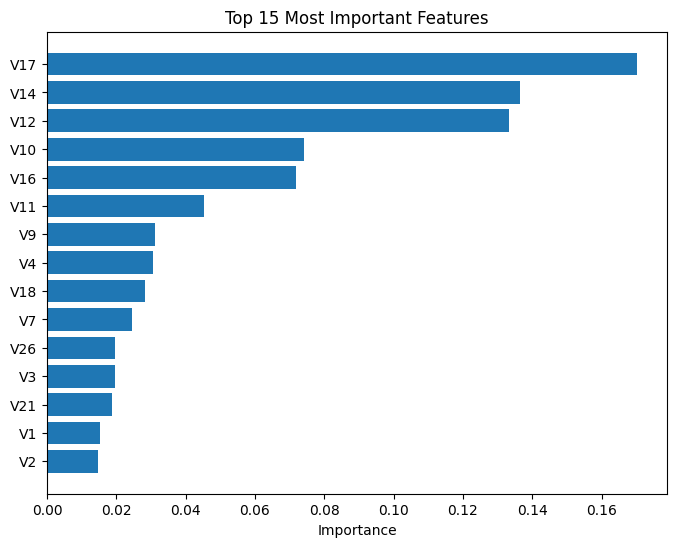

In [ ]:
top_features = feature_importance.head(15)

plt.figure(figsize=(8,6))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.title("Top 15 Most Important Features")

plt.gca().invert_yaxis()

plt.show()

##  Data Preprocessing and Train-Test Split

In [ ]:
#making a list of top 12 features
top_features = feature_importance["Feature"].head(12).tolist()

#new dataset
X_selected = X[top_features]

#Train test data split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.999614,0.941860,0.826531,0.880435
4,KNN,0.999561,0.910112,0.826531,0.866310
3,SVM,0.999473,0.959459,0.724490,0.825581
1,Decision Tree,0.999192,0.760000,0.775510,0.767677
0,Logistic Regression,0.999105,0.813333,0.622449,0.705202
